1. Introduction

This notebook builds a professional credit scoring model to predict loan default risk.

Objective: Predict if a customer will default (binary), provide default probability (PD: 0-1), compute a credit score (300-850 range), and assign risk bands (Very Low Risk to Very High Risk).
Data: Lending Club loan data (2007-2014) with 466k rows, 75 columns.
Approach: Detailed EDA → Preprocessing → Modeling (with tuning) → Evaluation → Scoring & Banding.
Improvements: Structured workflow, handling imbalance, model comparison, calibration, visualizations, detailed statistical EDA with univariate/bivariate/multivariate analysis.

2. Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score
)
from scipy.stats import ks_2samp, chi2_contingency, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42

# Mount Google Drive (if using Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 3. Data Loading
Load the dataset and perform initial checks.

In [ ]:
path = "/content/drive/MyDrive/loan_data_2007_2014.csv"

df = pd.read_csv(path, low_memory=False)
df.columns = df.columns.str.strip()  # Clean column names

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values Summary:")
missing_summary = df.isnull().mean() * 100
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

Shape: (466285, 75)

First 5 rows:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-nul

4. Exploratory Data Analysis (EDA)
Understand distributions, correlations, and target imbalance.
Detailed:
Univariate: Stats, distributions, skewness/kurtosis for num; counts for cat.
Bivariate: Correlations (num-num), ANOVA/boxplots (num-cat), Chi-square/Cramer's V/crosstabs (cat-cat), all vs target.
Multivariate: Pairplots, VIF for collinearity.
Target distributions: Included in univariate and bivariate.
Missing data: Detailed % by group, difference, heatmap visualization.

Useful numeric columns (39): ['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths'] ...
Useful categorical columns (10): ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']

1. Univariate Analysis


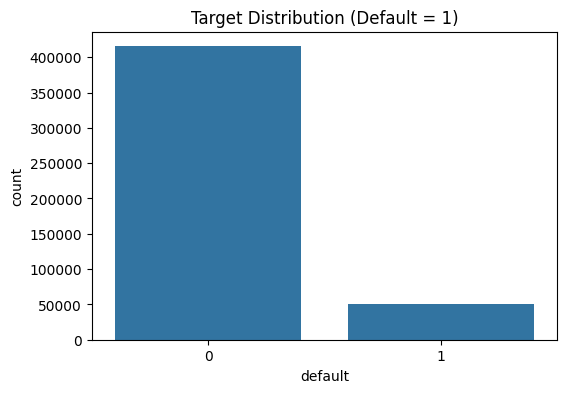

Target Proportions:
 default
0    89.07
1    10.93
Name: proportion, dtype: float64


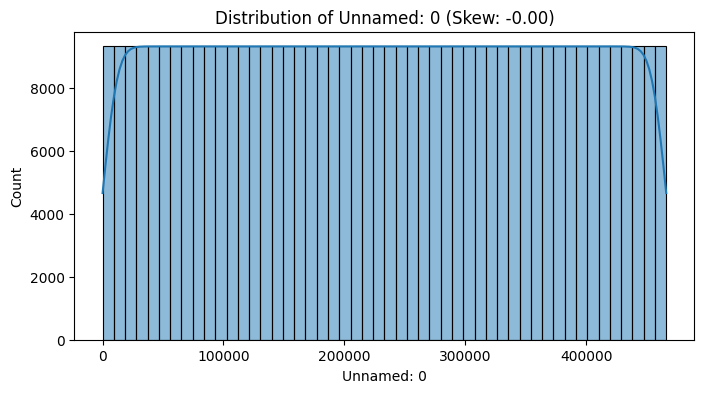

Unnamed: 0 - Stats:
count    466285.00
mean     233142.00
std      134605.03
min           0.00
25%      116571.00
50%      233142.00
75%      349713.00
max      466284.00
Name: Unnamed: 0, dtype: float64


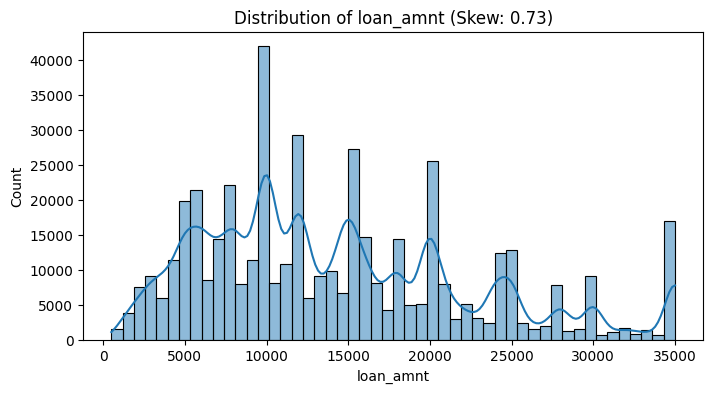

loan_amnt - Stats:
count    466285.00
mean      14317.28
std        8286.51
min         500.00
25%        8000.00
50%       12000.00
75%       20000.00
max       35000.00
Name: loan_amnt, dtype: float64


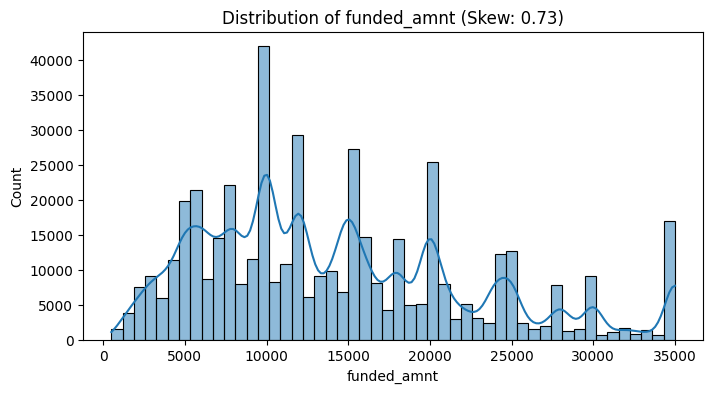

funded_amnt - Stats:
count    466285.00
mean      14291.80
std        8274.37
min         500.00
25%        8000.00
50%       12000.00
75%       20000.00
max       35000.00
Name: funded_amnt, dtype: float64


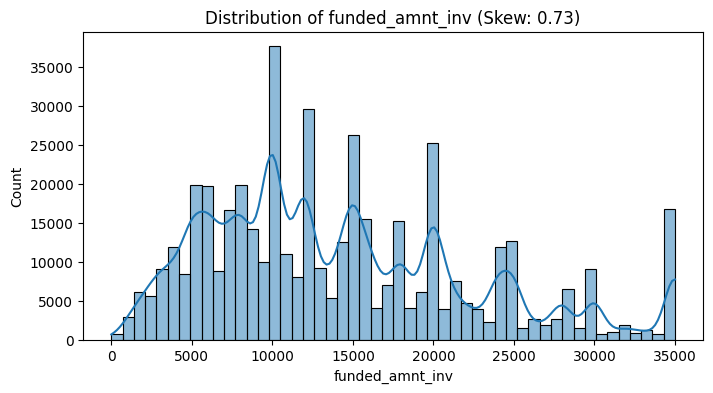

funded_amnt_inv - Stats:
count    466285.00
mean      14222.33
std        8297.64
min           0.00
25%        8000.00
50%       12000.00
75%       19950.00
max       35000.00
Name: funded_amnt_inv, dtype: float64


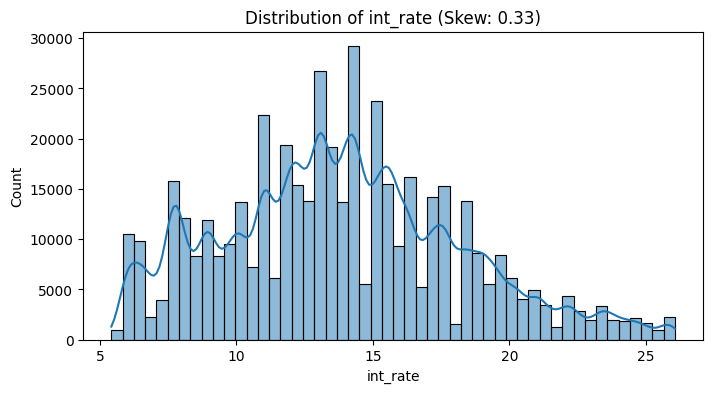

int_rate - Stats:
count    466285.00
mean         13.83
std           4.36
min           5.42
25%          10.99
50%          13.66
75%          16.49
max          26.06
Name: int_rate, dtype: float64


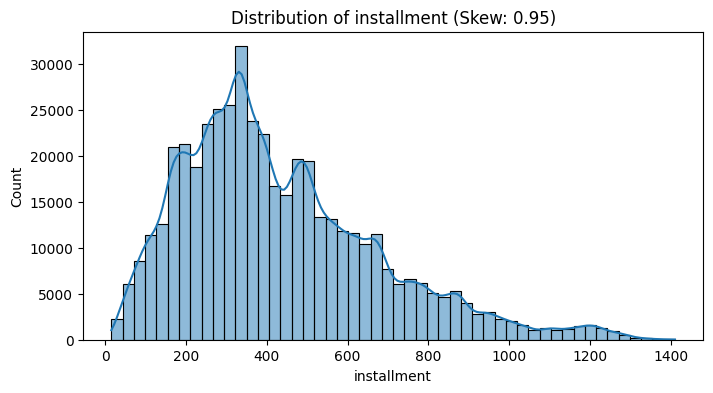

installment - Stats:
count    466285.00
mean        432.06
std         243.49
min          15.67
25%         256.69
50%         379.89
75%         566.58
max        1409.99
Name: installment, dtype: float64


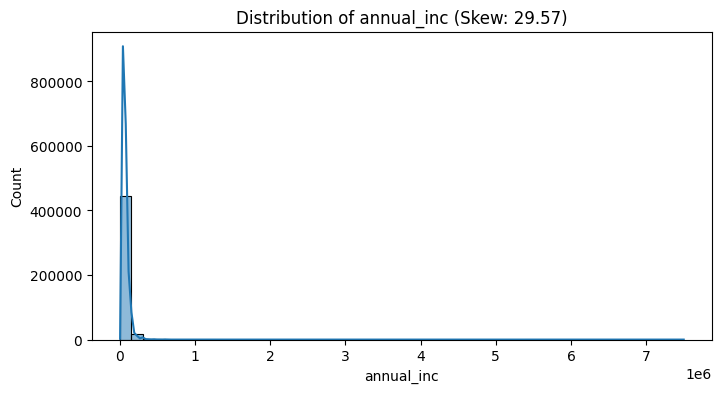

annual_inc - Stats:
count     466281.00
mean       73277.38
std        54963.57
min         1896.00
25%        45000.00
50%        63000.00
75%        88960.00
max      7500000.00
Name: annual_inc, dtype: float64


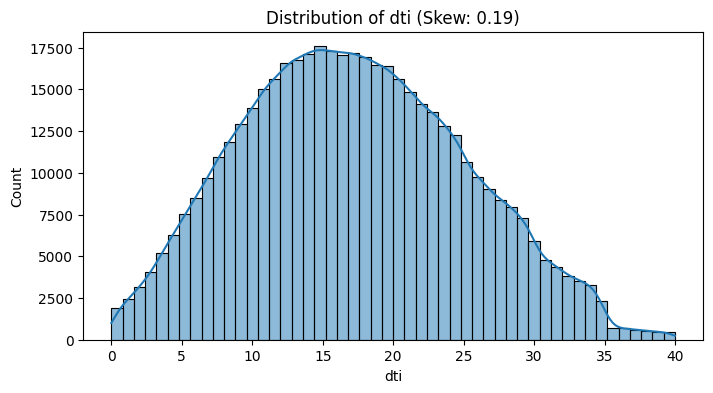

dti - Stats:
count    466285.00
mean         17.22
std           7.85
min           0.00
25%          11.36
50%          16.87
75%          22.78
max          39.99
Name: dti, dtype: float64


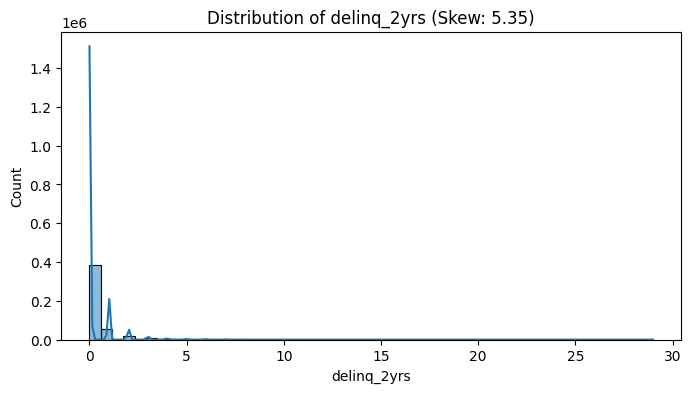

delinq_2yrs - Stats:
count    466256.00
mean          0.28
std           0.80
min           0.00
25%           0.00
50%           0.00
75%           0.00
max          29.00
Name: delinq_2yrs, dtype: float64


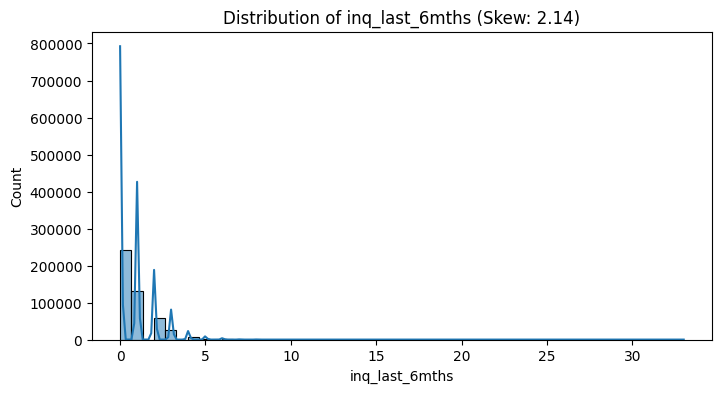

inq_last_6mths - Stats:
count    466256.00
mean          0.80
std           1.09
min           0.00
25%           0.00
50%           0.00
75%           1.00
max          33.00
Name: inq_last_6mths, dtype: float64


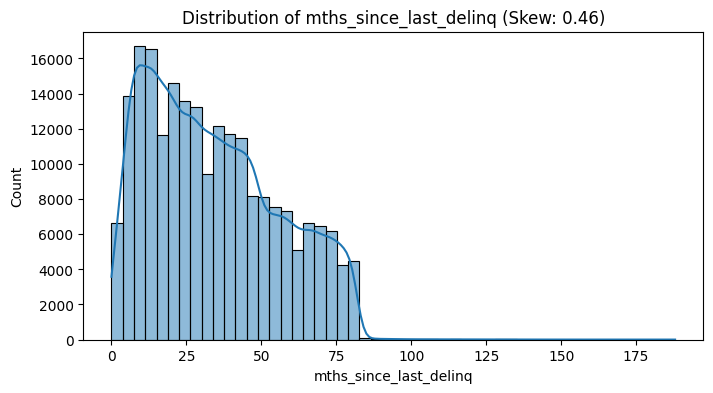

mths_since_last_delinq - Stats:
count    215934.00
mean         34.10
std          21.78
min           0.00
25%          16.00
50%          31.00
75%          49.00
max         188.00
Name: mths_since_last_delinq, dtype: float64


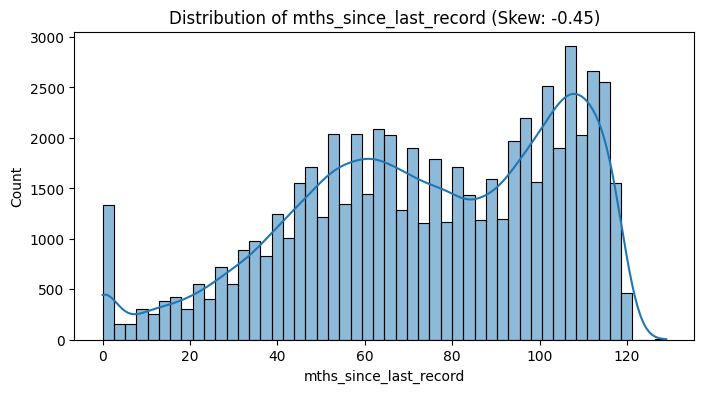

mths_since_last_record - Stats:
count    62638.00
mean        74.31
std         30.36
min          0.00
25%         53.00
50%         76.00
75%        102.00
max        129.00
Name: mths_since_last_record, dtype: float64


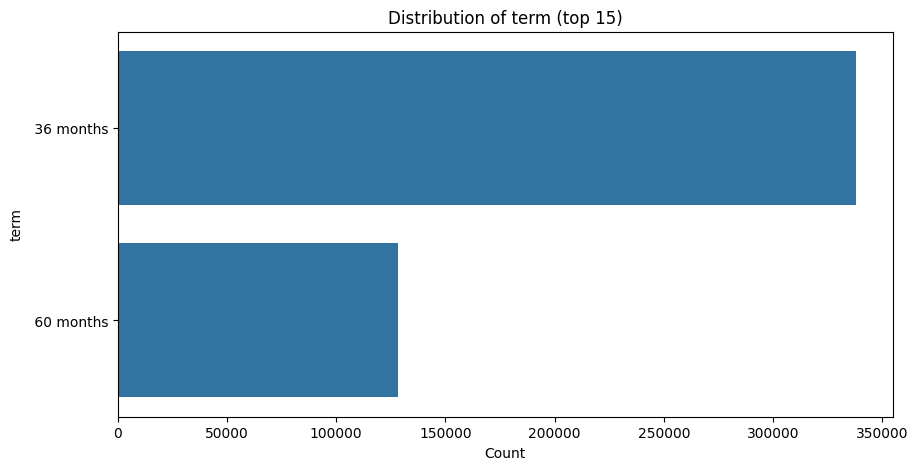

term - Top 10 proportions:
term
36 months    72.48
60 months    27.52
Name: proportion, dtype: float64


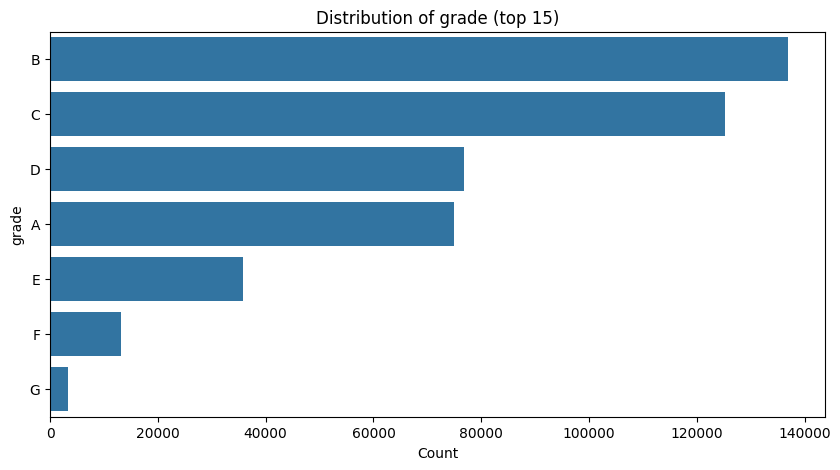

grade - Top 10 proportions:
grade
B    29.37
C    26.87
D    16.49
A    16.06
E     7.67
F     2.84
G     0.71
Name: proportion, dtype: float64


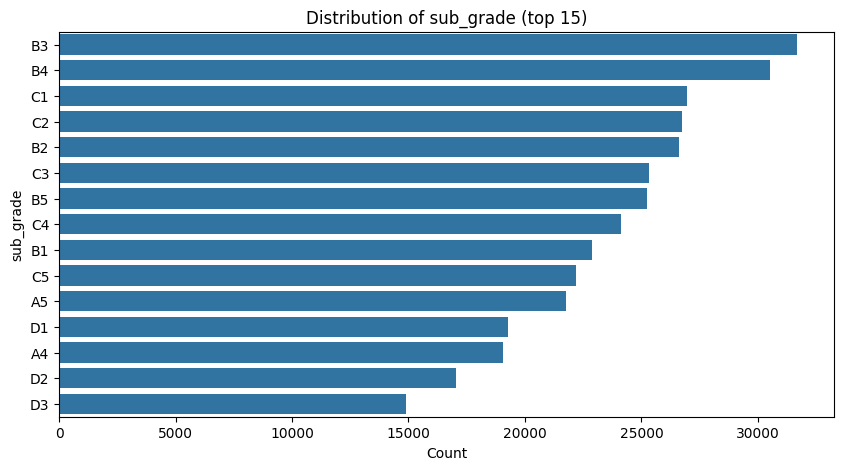

sub_grade - Top 10 proportions:
sub_grade
B3    6.80
B4    6.54
C1    5.78
C2    5.73
B2    5.71
C3    5.43
B5    5.42
C4    5.17
B1    4.91
C5    4.76
Name: proportion, dtype: float64


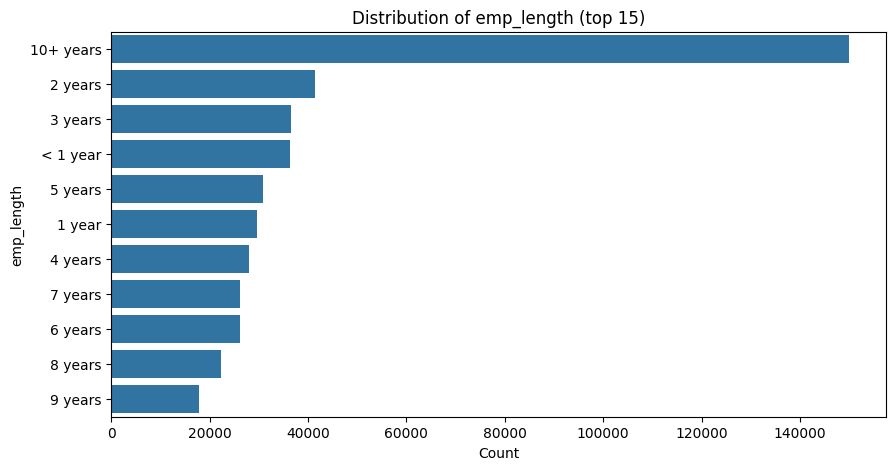

emp_length - Top 10 proportions:
emp_length
10+ years    33.70
2 years       9.29
3 years       8.22
< 1 year      8.14
5 years       6.91
1 year        6.65
4 years       6.29
7 years       5.88
6 years       5.86
8 years       5.03
Name: proportion, dtype: float64


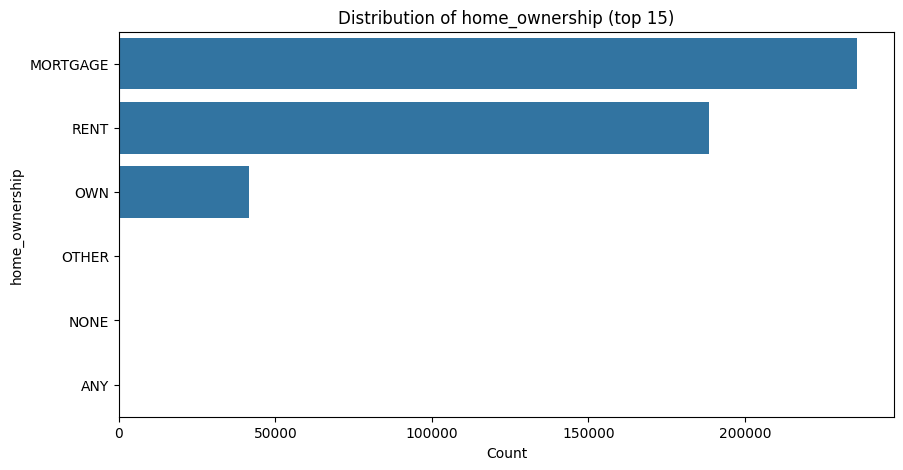

home_ownership - Top 10 proportions:
home_ownership
MORTGAGE    50.59
RENT        40.42
OWN          8.94
OTHER        0.04
NONE         0.01
ANY          0.00
Name: proportion, dtype: float64


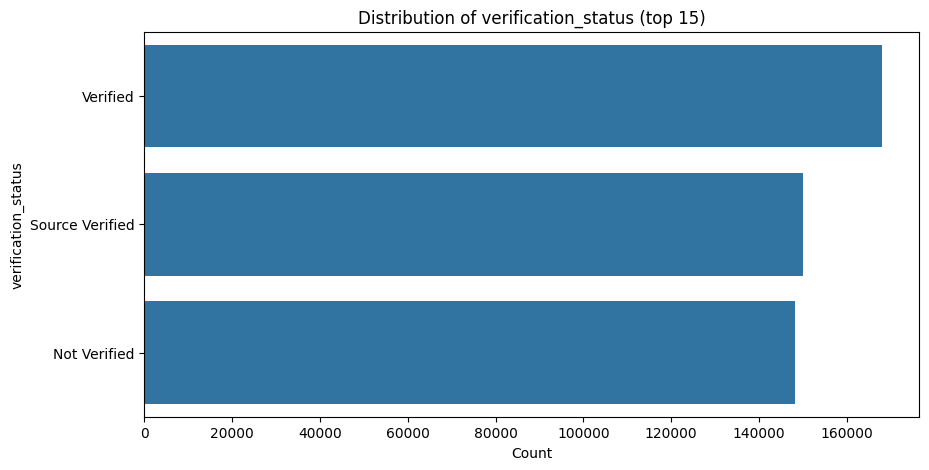

verification_status - Top 10 proportions:
verification_status
Verified           36.04
Source Verified    32.17
Not Verified       31.79
Name: proportion, dtype: float64


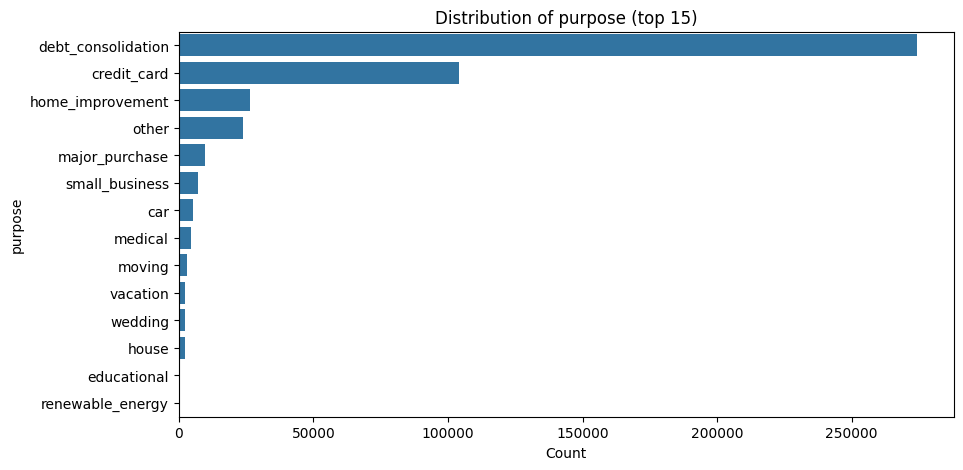

purpose - Top 10 proportions:
purpose
debt_consolidation    58.80
credit_card           22.34
home_improvement       5.69
other                  5.08
major_purchase         2.11
small_business         1.50
car                    1.16
medical                0.99
moving                 0.64
vacation               0.53
Name: proportion, dtype: float64


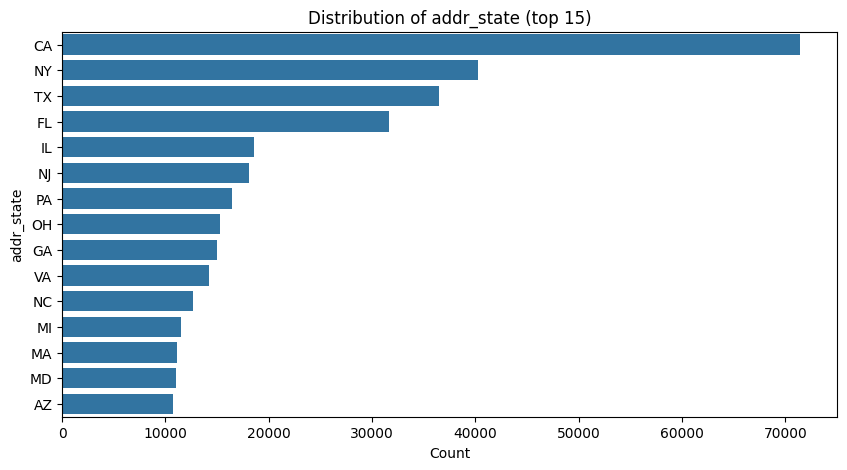

addr_state - Top 10 proportions:
addr_state
CA    15.32
NY     8.63
TX     7.81
FL     6.78
IL     3.99
NJ     3.87
PA     3.52
OH     3.27
GA     3.21
VA     3.05
Name: proportion, dtype: float64

2. Bivariate vs Target (Default)


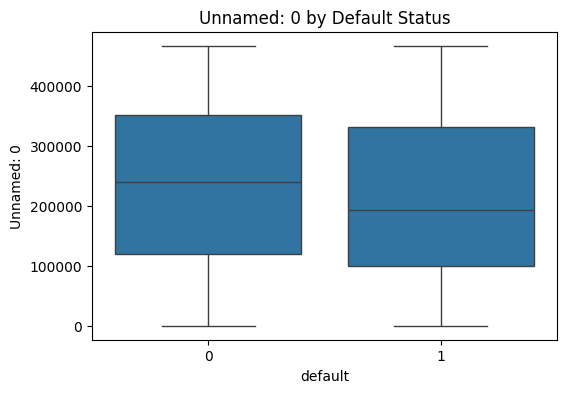

Unnamed: 0 mean: Non-default = 235806.01, Default = 211434.11, Diff = -24371.89


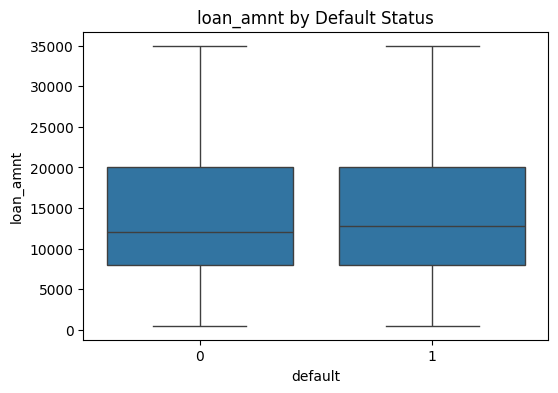

loan_amnt mean: Non-default = 14282.97, Default = 14596.85, Diff = 313.89


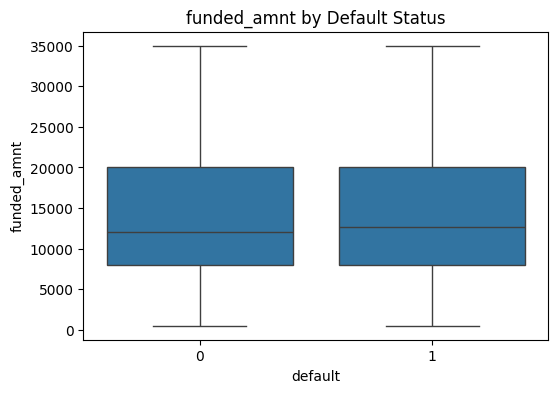

funded_amnt mean: Non-default = 14259.91, Default = 14551.70, Diff = 291.79


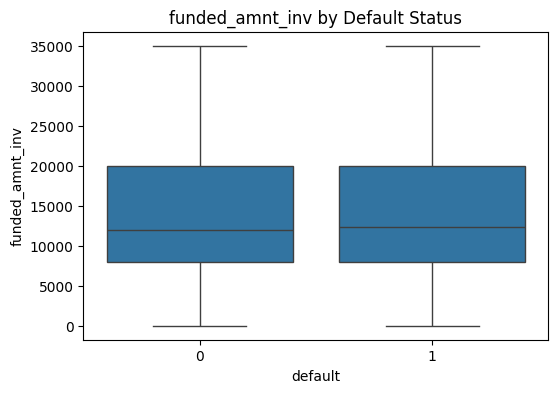

funded_amnt_inv mean: Non-default = 14201.43, Default = 14392.67, Diff = 191.24


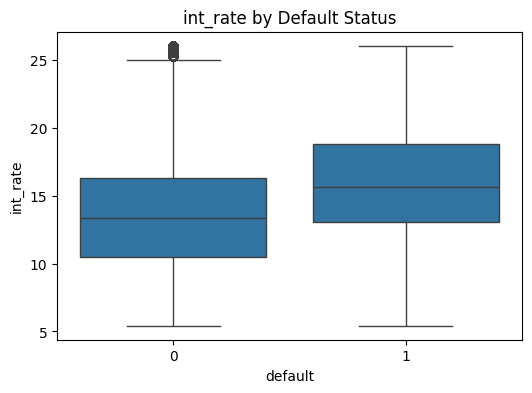

int_rate mean: Non-default = 13.57, Default = 15.97, Diff = 2.41


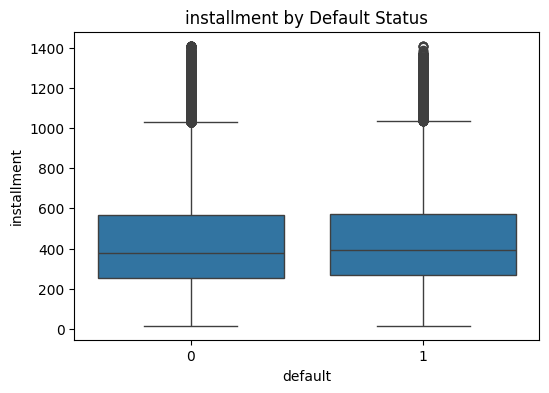

installment mean: Non-default = 430.87, Default = 441.75, Diff = 10.87


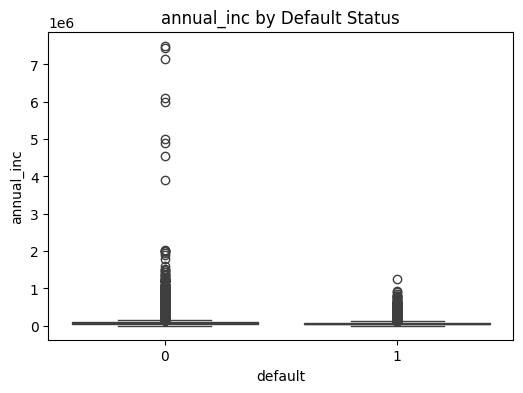

annual_inc mean: Non-default = 74237.49, Default = 65453.94, Diff = -8783.55


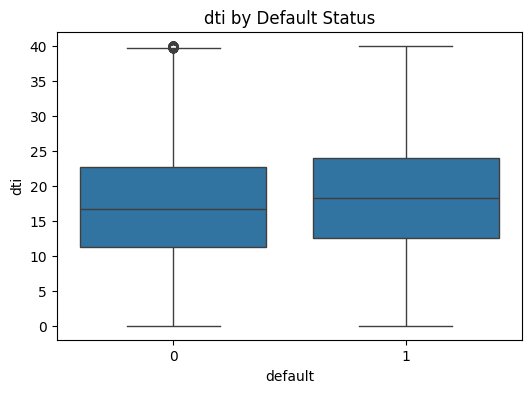

dti mean: Non-default = 17.09, Default = 18.30, Diff = 1.21


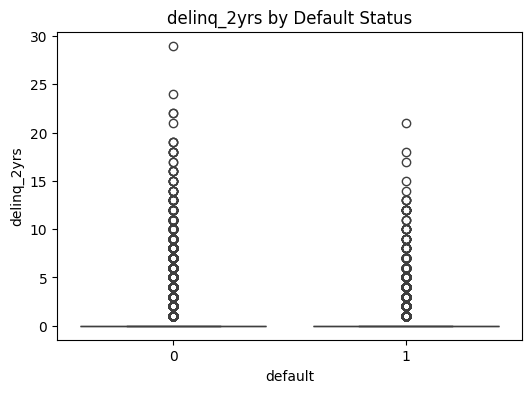

delinq_2yrs mean: Non-default = 0.28, Default = 0.29, Diff = 0.00


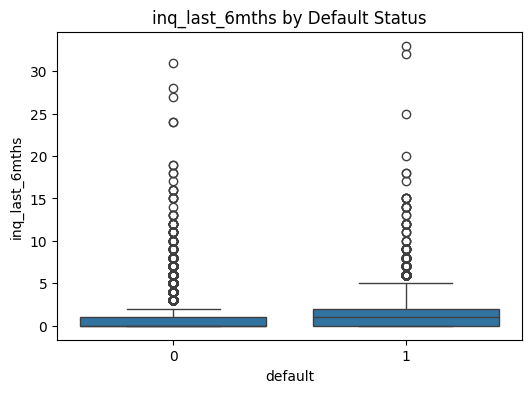

inq_last_6mths mean: Non-default = 0.78, Default = 1.03, Diff = 0.26


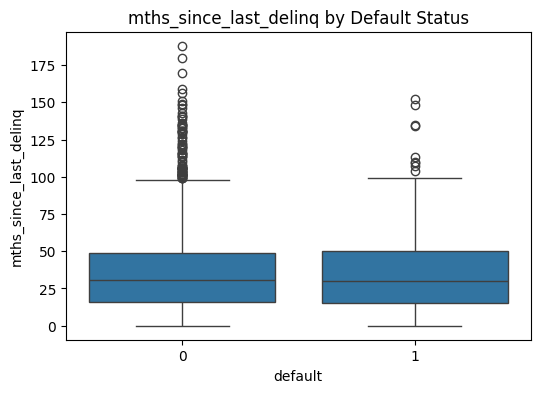

mths_since_last_delinq mean: Non-default = 34.13, Default = 33.90, Diff = -0.23


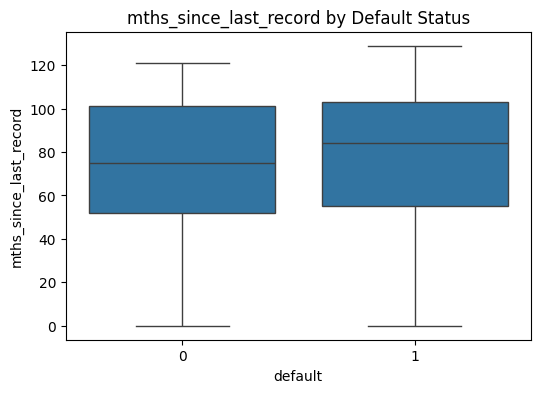

mths_since_last_record mean: Non-default = 74.07, Default = 76.32, Diff = 2.25


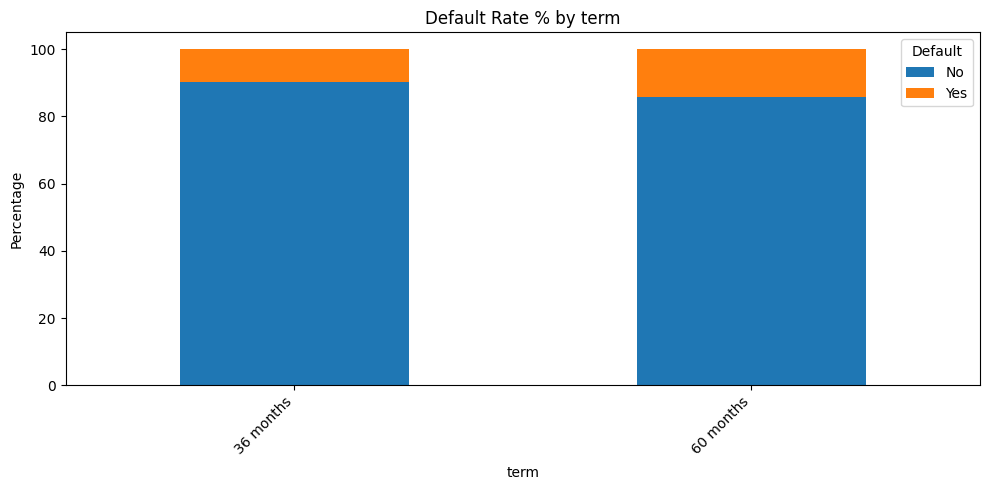

Top 5 highest default rates in term:
term
60 months    14.15
36 months     9.71
Name: 1, dtype: float64%


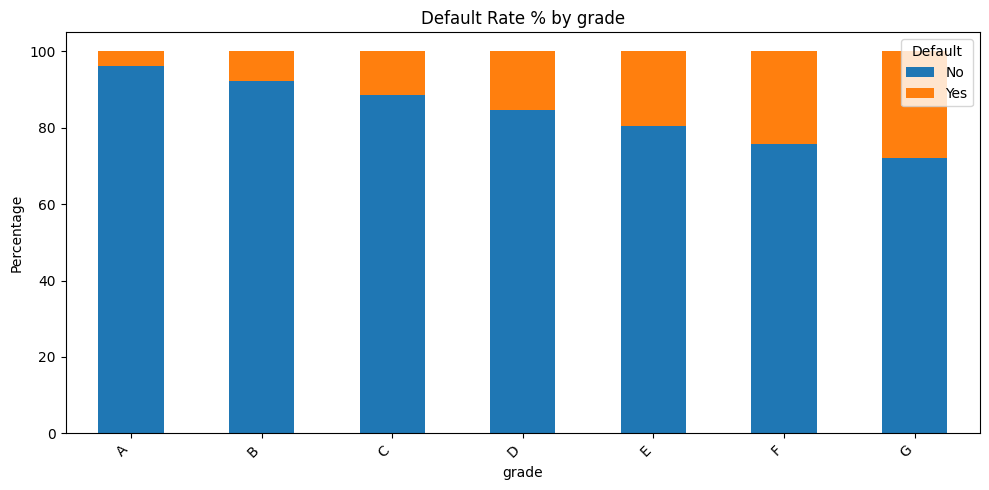

Top 5 highest default rates in grade:
grade
G    27.81
F    24.13
E    19.48
D    15.41
C    11.48
Name: 1, dtype: float64%


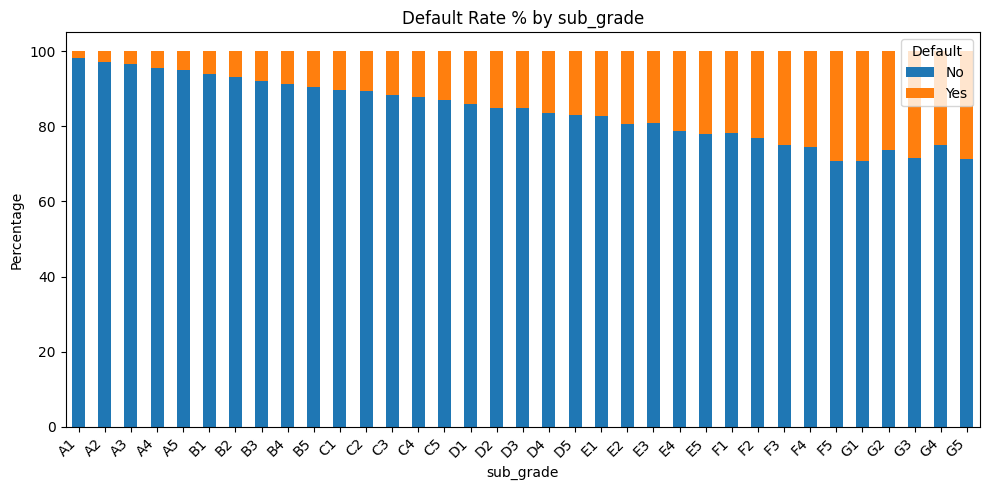

Top 5 highest default rates in sub_grade:
sub_grade
G1    29.31
F5    29.15
G5    28.83
G3    28.47
G2    26.37
Name: 1, dtype: float64%


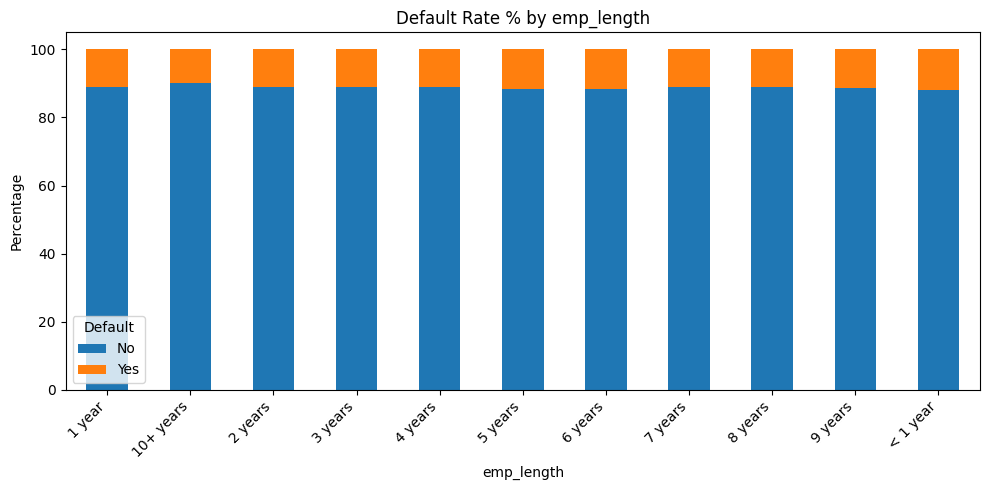

Top 5 highest default rates in emp_length:
emp_length
< 1 year    11.90
6 years     11.71
5 years     11.50
9 years     11.21
1 year      11.19
Name: 1, dtype: float64%


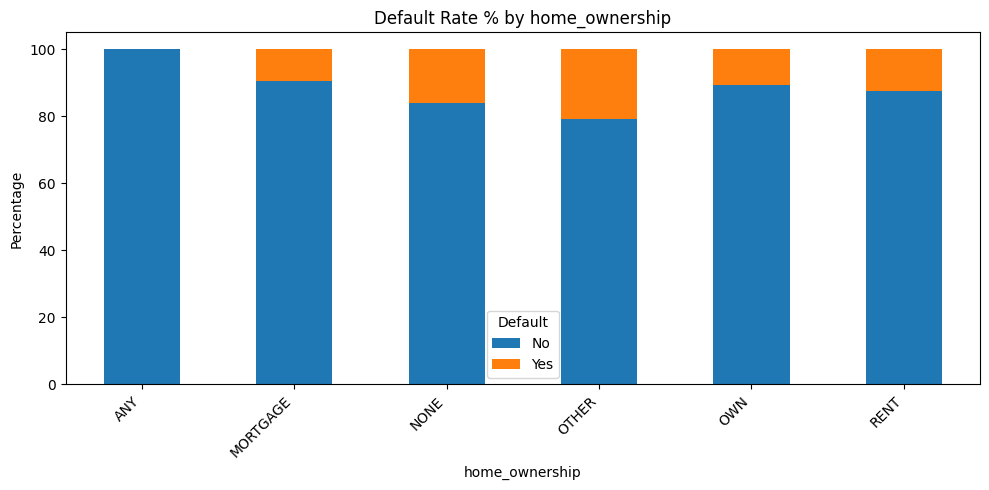

Top 5 highest default rates in home_ownership:
home_ownership
OTHER       20.88
NONE        16.00
RENT        12.61
OWN         10.83
MORTGAGE     9.60
Name: 1, dtype: float64%


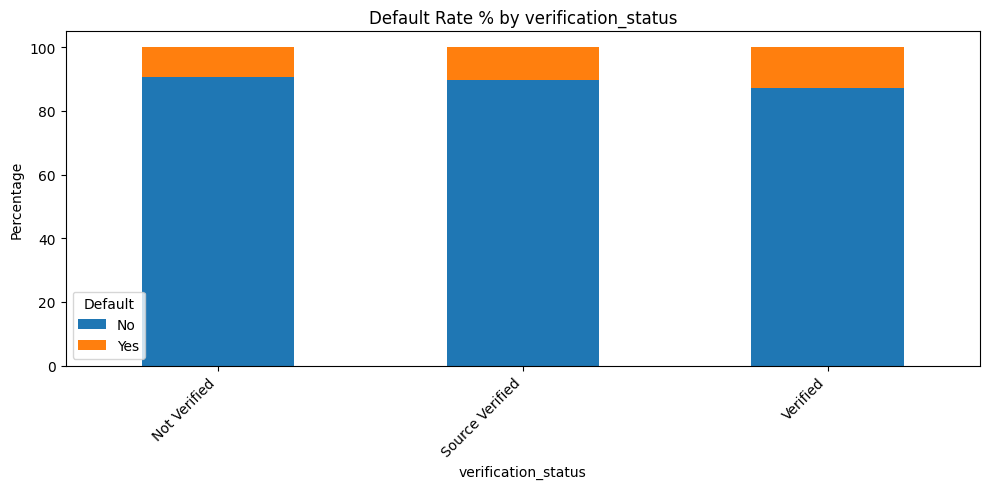

Top 5 highest default rates in verification_status:
verification_status
Verified           12.74
Source Verified    10.41
Not Verified        9.41
Name: 1, dtype: float64%


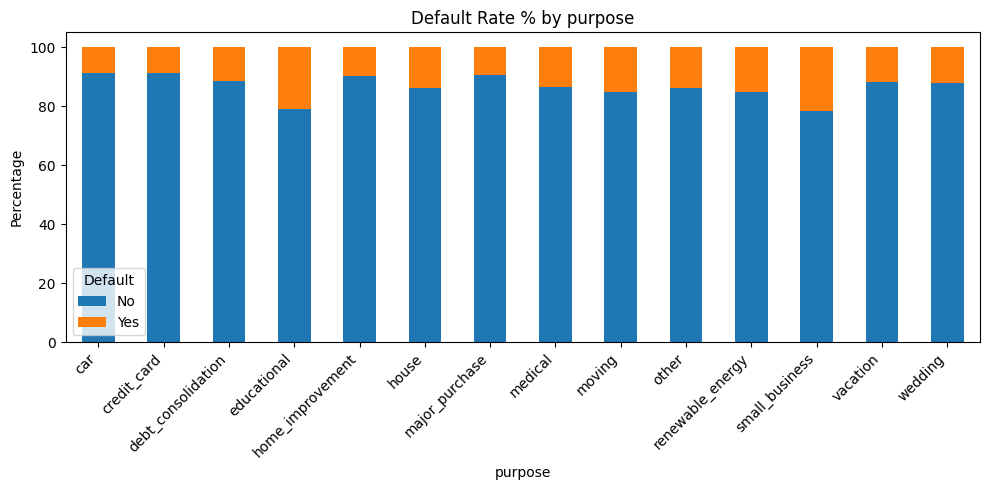

Top 5 highest default rates in purpose:
purpose
small_business      21.57
educational         20.85
renewable_energy    15.38
moving              15.26
house               14.01
Name: 1, dtype: float64%


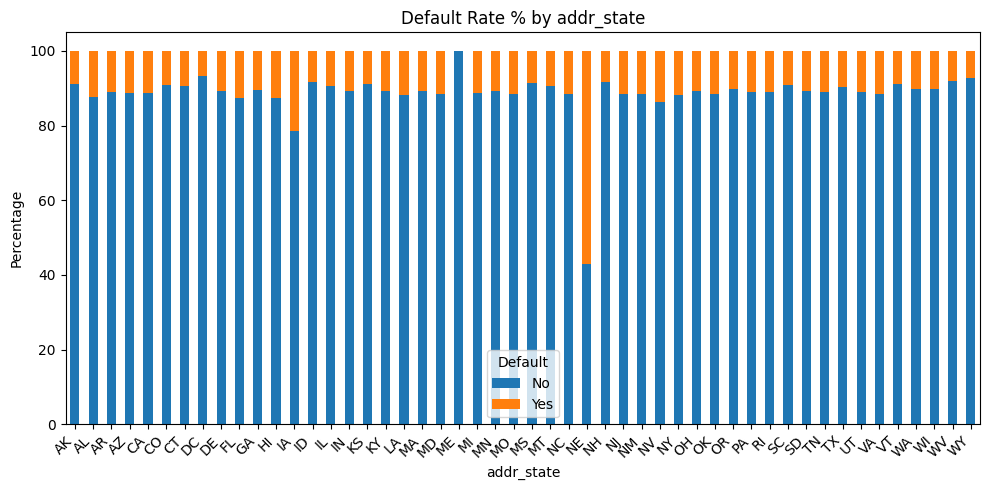

Top 5 highest default rates in addr_state:
addr_state
NE    57.14
IA    21.43
NV    13.71
HI    12.63
FL    12.54
Name: 1, dtype: float64%

3. Correlations & Collinearity


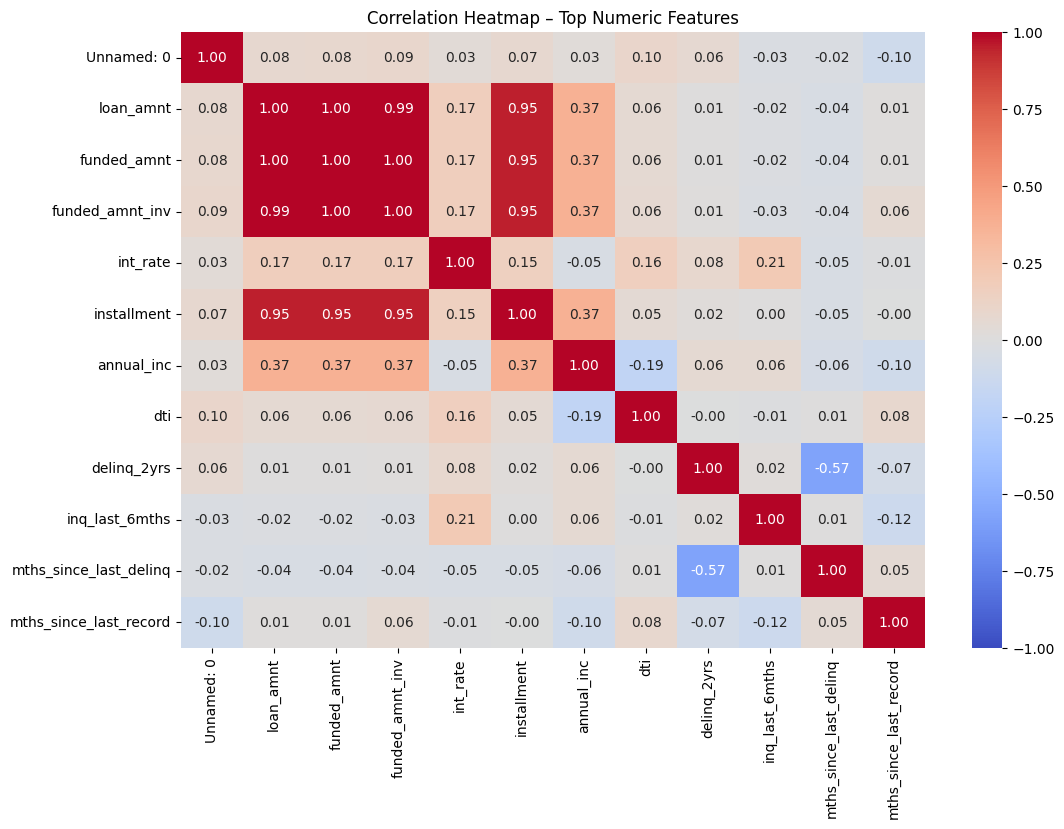

=== Multivariate Analysis – Collinearity (VIF) ===
Skipping constant columns: ['const']

Variance Inflation Factor (VIF) Results:
VIF > 10: Strong multicollinearity – consider dropping/combining
VIF 5–10: Moderate – monitor
VIF < 5: Low collinearity – good
                        Feature           VIF
0                   total_pymnt  1.305391e+14
1               total_rec_prncp  8.263486e+13
2                 total_rec_int  8.278676e+12
3                    recoveries  2.008608e+11
4            total_rec_late_fee  1.810994e+07
5                     out_prncp  4.275450e+05
6                 out_prncp_inv  4.274757e+05
7                   funded_amnt  4.853150e+03
8               funded_amnt_inv  3.308790e+03
9               total_pymnt_inv  2.295250e+03
10                    loan_amnt  1.395900e+03
11                  installment  6.564000e+01
12       mths_since_last_record  2.590000e+01
13                     int_rate  2.206000e+01
14  mths_since_last_major_derog  2.085000e+01
15     

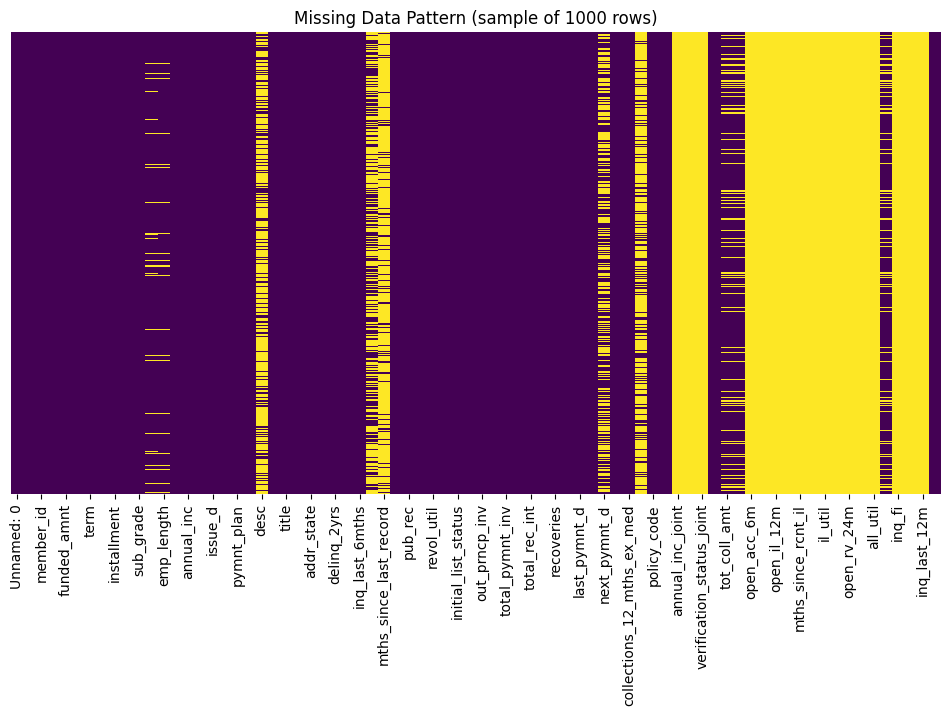

Key insight: If missing % is much higher for defaulters, consider adding missing flags.


In [ ]:
# Detailed EDA

# Create target
bad_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']
if 'default' not in df.columns:
    df['default'] = np.where(df['loan_status'].isin(bad_status), 1, 0)

# Identify meaningful columns – exclude junk/leaky/high-cardinality
exclude_patterns = ['Unnamed', 'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'emp_title', 'loan_status', 'policy_code']
leaky_keywords = ['pymnt', 'recov', 'out_prncp', 'last_pymnt', 'last_credit', 'total_rec', 'hardship', 'settlement', 'collections', 'fico_range']

useful_num_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns
                   if col != 'default' and not any(p in col.lower() for p in exclude_patterns + leaky_keywords)]

useful_cat_cols = [col for col in df.select_dtypes(include=['object']).columns
                   if not any(p in col.lower() for p in exclude_patterns + leaky_keywords) and df[col].nunique() <= 50]

print(f"Useful numeric columns ({len(useful_num_cols)}):", useful_num_cols[:10], "...")
print(f"Useful categorical columns ({len(useful_cat_cols)}):", useful_cat_cols)

# Limit for plotting (avoid crash)
plot_num_cols = useful_num_cols[:12]  # top 12 numerics
plot_cat_cols = useful_cat_cols[:8]   # top 8 categoricals

# 1. Univariate Analysis
print("\n1. Univariate Analysis")

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title('Target Distribution (Default = 1)')
plt.show()
print("Target Proportions:\n", df['default'].value_counts(normalize=True).round(4) * 100)

# Numeric univariate
for col in plot_num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f'Distribution of {col} (Skew: {df[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
    print(f"{col} - Stats:\n{df[col].describe().round(2)}")

# Categorical univariate
for col in plot_cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(y=df[col], order=df[col].value_counts().index[:15])
    plt.title(f'Distribution of {col} (top 15)')
    plt.xlabel('Count')
    plt.show()
    print(f"{col} - Top 10 proportions:\n{df[col].value_counts(normalize=True).head(10).round(4)*100}")

# 2. Bivariate Analysis vs Target
print("\n2. Bivariate vs Target (Default)")

# Numeric vs Target – Boxplots + mean difference
for col in plot_num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='default', y=col, data=df)
    plt.title(f'{col} by Default Status')
    plt.show()
    means = df.groupby('default')[col].mean()
    print(f"{col} mean: Non-default = {means[0]:.2f}, Default = {means[1]:.2f}, Diff = {means[1]-means[0]:.2f}")

# Categorical vs Target – Stacked bar (default rate %)
for col in plot_cat_cols:
    crosstab = pd.crosstab(df[col], df['default'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, figsize=(10,5))
    plt.title(f'Default Rate % by {col}')
    plt.ylabel('Percentage')
    plt.legend(title='Default', labels=['No', 'Yes'])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(f"Top 5 highest default rates in {col}:\n{crosstab[1].sort_values(ascending=False).head(5).round(2)}%")

# 3. Correlations & Collinearity
print("\n3. Correlations & Collinearity")

# Num-Num correlation heatmap (top 15 features)
top_num = df[plot_num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(top_num, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap – Top Numeric Features')
plt.show()

# Multivariate Collinearity Check – Safe VIF Calculation
# Define numeric columns safely (exclude target)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('default', errors='ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("=== Multivariate Analysis – Collinearity (VIF) ===")

# Use only useful numeric columns (exclude IDs, constants, leaked ones if any still present)
useful_num_for_vif = [col for col in num_cols if col not in ['id', 'member_id', 'Unnamed: 0'] and df[col].nunique() > 1]

if len(useful_num_for_vif) == 0:
    print("No suitable numeric columns for VIF (all constant or empty). Skipping.")
else:
    # Fill missing values temporarily for VIF (median – same as preprocessing)
    vif_df = df[useful_num_for_vif].copy()
    vif_df = vif_df.fillna(vif_df.median())

    # Add constant term
    vif_data = add_constant(vif_df)

    # Remove any remaining constant columns (VIF infinite or undefined)
    constant_cols = [col for col in vif_data.columns if vif_data[col].nunique() <= 1]
    if constant_cols:
        print(f"Skipping constant columns: {constant_cols}")
        vif_data = vif_data.drop(columns=constant_cols)

    if vif_data.shape[1] <= 1:
        print("No valid columns left for VIF calculation after cleaning.")
    else:
        # Compute VIF
        vif_results = pd.DataFrame()
        vif_results["Feature"] = vif_data.columns
        vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i)
                              for i in range(vif_data.shape[1])]

        # Drop constant row
        vif_results = vif_results[vif_results["Feature"] != "const"]
        vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

        print("\nVariance Inflation Factor (VIF) Results:")
        print("VIF > 10: Strong multicollinearity – consider dropping/combining")
        print("VIF 5–10: Moderate – monitor")
        print("VIF < 5: Low collinearity – good")
        print(vif_results.round(2))

        # Highlight high VIF
        high_vif = vif_results[vif_results['VIF'] > 10]
        if not high_vif.empty:
            print("\nHigh VIF features (potential action needed):")
            print(high_vif)
        else:
            print("\nNo strong multicollinearity detected (all VIF < 10).")

# 4. Missing Data Detailed View
print("\n4. Missing Data Patterns")

# Missing % by column
missing_pct = df.isnull().mean() * 100
print("Top 15 columns by missing %:\n", missing_pct.sort_values(ascending=False).head(15).round(2))

# Missing by target group
missing_by_default = df.groupby('default').apply(lambda x: x.isnull().mean() * 100).T
missing_diff = (missing_by_default[1] - missing_by_default[0]).sort_values(ascending=False)
print("\nMissing % difference (defaulters - non-defaulters) – top 15:")
print(missing_diff.head(15).round(2))

# Missingness heatmap (sample 1000 rows for speed)
plt.figure(figsize=(12,6))
sns.heatmap(df.sample(1000).isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Pattern (sample of 1000 rows)')
plt.show()

print("Key insight: If missing % is much higher for defaulters, consider adding missing flags.")

Added missing indicators for predictive missing column

In [ ]:
# 5. Data Preprocessing

print("Starting advanced preprocessing...")

# STEP 1: Add missing indicators for predictive missingness
# Fallback: recompute missing_diff if not present
if 'missing_diff' not in globals():
    print("Recomputing missing_diff (fallback)...")
    missing_by_group = df.groupby('default').apply(lambda x: x.isnull().mean() * 100).T
    missing_diff = (missing_by_group[1] - missing_by_group[0]).sort_values(ascending=False)

# Threshold: flag columns where missing % is >5% higher among defaulters
predictive_missing_cols = missing_diff[missing_diff > 5].index.tolist()

print(f"\nAdding missing indicators for {len(predictive_missing_cols)} columns "
      f"(missing >5% higher among defaulters):")
if predictive_missing_cols:
    print(", ".join(predictive_missing_cols))
else:
    print("No strongly predictive missingness found.")

for col in predictive_missing_cols:
    if col in df.columns and col != 'default':
        df[col + '_missing'] = df[col].isnull().astype(int)
        print(f"  → Added flag: {col}_missing")

# STEP 2: Define columns to drop – selective & safe
irrelevant_cols = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title',
    'emp_title', 'zip_code'  # addr_state kept – potentially useful
]

leakage_and_internal_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'last_credit_pull_d',
    'out_prncp', 'out_prncp_inv', 'delinq_amnt',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'debt_settlement_flag', 'loan_status', 'policy_code',
    'grade', 'sub_grade', 'funded_amnt', 'funded_amnt_inv', 'installment',
    'application_type', 'disbursement_method'
]

# Very relaxed: only drop if >80% missing
high_missing_cols = [col for col in df.columns if df[col].isnull().mean() > 0.80]

drop_cols = list(set(irrelevant_cols + leakage_and_internal_cols + high_missing_cols))

print(f"\nDropping {len(drop_cols)} columns (irrelevant + leaky + >80% missing):")
if drop_cols:
    print(", ".join(drop_cols[:15]), "..." if len(drop_cols) > 15 else "")
else:
    print("No columns dropped.")

df = df.drop(columns=drop_cols, errors='ignore')

# Safety check
if 'loan_status' in df.columns:
    print("!!! WARNING: 'loan_status' still present – remove manually !!!")
else:
    print("Good: 'loan_status' removed.")

# STEP 3: Update column lists after changes
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('default', errors='ignore')
cat_cols = df.select_dtypes(include=['object']).columns

print(f"\nRemaining: {len(num_cols)} numeric + {len(cat_cols)} categorical = {len(num_cols) + len(cat_cols)} features")

# STEP 4: Impute remaining missing values
print("\nImputing missing values...")
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Safe mode imputation with fallback
for col in cat_cols:
    mode_series = df[col].mode()
    fill_value = mode_series.iloc[0] if not mode_series.empty else 'Unknown'
    df[col] = df[col].fillna(fill_value)

print("Imputation complete. Remaining missing values:", df.isnull().sum().sum())

# STEP 5: Date-derived features (safe & checked)
print("\nCreating date-derived features...")
date_cols_processed = 0
for date_col in ['issue_d', 'earliest_cr_line']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], format='%b-%y', errors='coerce')
        date_cols_processed += 1

        if date_col == 'issue_d':
            df['issue_year'] = df[date_col].dt.year
            df['issue_month'] = df[date_col].dt.month.fillna(-1).astype(int)
        else:
            df['credit_history_years'] = (pd.to_datetime('today') - df[date_col]).dt.days / 365.25
            df['credit_history_years'] = df['credit_history_years'].fillna(df['credit_history_years'].median())

        df = df.drop(date_col, axis=1)

if date_cols_processed == 0:
    print("No date columns found to process (already removed or not present).")
else:
    print(f"Processed {date_cols_processed} date columns.")

# STEP 6: Final train/test split
print("\nFinal train/test split...")
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Features used: {X_train.shape[1]}")
print("\nSample columns:", X_train.columns[:12].tolist(), "...")

Starting advanced preprocessing...

Adding missing indicators for 4 columns (missing >5% higher among defaulters):
next_pymnt_d, tot_cur_bal, total_rev_hi_lim, tot_coll_amt
  → Added flag: next_pymnt_d_missing
  → Added flag: tot_cur_bal_missing
  → Added flag: total_rev_hi_lim_missing
  → Added flag: tot_coll_amt_missing

Dropping 52 columns (irrelevant + leaky + >80% missing):
total_bal_il, open_il_6m, last_fico_range_high, debt_settlement_flag, all_util, last_fico_range_low, total_rec_prncp, total_pymnt_inv, policy_code, total_cu_tl, open_rv_24m, sub_grade, open_acc_6m, last_pymnt_d, out_prncp_inv ...
Good: 'loan_status' removed.

Remaining: 22 numeric + 11 categorical = 33 features

Imputing missing values...
Imputation complete. Remaining missing values: 0

Creating date-derived features...
Processed 2 date columns.

Final train/test split...
Train shape: (373028, 34) | Test shape: (93257, 34)
Features used: 34

Sample columns: ['loan_amnt', 'term', 'int_rate', 'emp_length', 'home

# 6. Modeling Pipeline
- Use pipelines for preprocessing + modeling.
- Models: Logistic Regression (interpretable) and Random Forest (non-linear).
- Tune hyperparameters with GridSearchCV.
- Handle imbalance with SMOTE.
- Calibrate probabilities for reliable PD.

In [ ]:
# 6. Modeling Pipeline – FIXED: Use CURRENT columns after preprocessing

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=== Modeling Pipeline – Using current columns after preprocessing ===")

# CRITICAL FIX: Re-define num_cols & cat_cols RIGHT HERE
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('default', errors='ignore')
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Current columns for modeling: {len(num_cols)} numeric + {len(cat_cols)} categorical = {len(num_cols) + len(cat_cols)} total")

# Verify columns exist in X_train
missing_cols = [col for col in num_cols if col not in X_train.columns] + \
               [col for col in cat_cols if col not in X_train.columns]
if missing_cols:
    print(f"WARNING: These columns are in lists but missing from X_train: {missing_cols}")
    print("→ This is likely why fit failed. Check cell #5 drops/renames.")
else:
    print("All columns present in X_train – good!")

# Define preprocessor with CURRENT columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'  # Drop any extra columns safely
)

# Models & grids
models = {
    'LogisticRegression': LogisticRegression(
        random_state=SEED,
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs'
    ),
    'RandomForest': RandomForestClassifier(
        random_state=SEED,
        class_weight='balanced_subsample',
        n_jobs=1
    )
}

param_grids = {
    'LogisticRegression': {'classifier__C': [0.1, 1.0, 10.0]},
    'RandomForest': {'classifier__n_estimators': [50, 100],
                     'classifier__max_depth': [10, 20, None]}
}

best_models = {}
best_cv_scores = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=1,
        verbose=1,
        return_train_score=True
    )

    try:
        grid.fit(X_train, y_train)
        best_models[name] = grid.best_estimator_
        best_cv_scores[name] = grid.best_score_

        print(f"{name} Best Params: {grid.best_params_}")
        print(f"{name} Best CV ROC AUC: {grid.best_score_:.4f}")
    except Exception as e:
        print(f"ERROR training {name}: {str(e)}")
        continue

    print(" ────────────────────────────────────────")

# Select best model
if best_cv_scores:
    best_model_name = max(best_cv_scores, key=best_cv_scores.get)
    best_model = best_models[best_model_name]

    print(f"\nBest overall model: {best_model_name}")
    print(f"CV ROC AUC: {best_cv_scores[best_model_name]:.4f}\n")
else:
    print("No models trained – check column lists or data in X_train.")
    raise ValueError("Training failed – see error above.")

# Calibrate
print("Calibrating probabilities ...")
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=3
)
calibrated_model.fit(X_train, y_train)

print("Calibration complete.")

# Save model
import joblib
joblib.dump(calibrated_model, 'credit_scoring_model_latest.pkl')
print("Model saved to 'credit_scoring_model_latest.pkl'")

=== Modeling Pipeline – Using current columns after preprocessing ===
Current columns for modeling: 24 numeric + 9 categorical = 33 total
All columns present in X_train – good!

Training LogisticRegression ...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
LogisticRegression Best Params: {'classifier__C': 1.0}
LogisticRegression Best CV ROC AUC: 0.7899
 ────────────────────────────────────────

Training RandomForest ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RandomForest Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
RandomForest Best CV ROC AUC: 0.7858
 ────────────────────────────────────────

Best overall model: LogisticRegression
CV ROC AUC: 0.7899

Calibrating probabilities ...
Calibration complete.
Model saved to 'credit_scoring_model_latest.pkl'


# 7. Model Evaluation
Evaluate on test set with multiple metrics.
- Binary prediction: Will default (1) or not (0).
- Focus on AUC, KS, Gini for credit risk.

MODEL RANKING POWER:
ROC AUC:           0.7860
Gini:              0.5720
KS Statistic:      0.4454
PR AUC:            0.3187
────────────────────────────────────────────────────────────

Default cutoff (threshold = 0.5):
  Accuracy:                  0.8914
  Precision (defaults):      0.5495
  Recall    (defaults):      0.0376
  F1-score  (defaults):      0.0703
  % Flagged as Risky:        0.7%
────────────────────────────────────────────────────────────

Chosen cutoff (threshold = 0.25):
  Accuracy:                  0.8574
  Precision (defaults):      0.3533
  Recall    (defaults):      0.3662
  F1-score  (defaults):      0.3596
  % Flagged as Risky:        11.3%
────────────────────────────────────────────────────────────

Confusion Matrix (Chosen threshold):


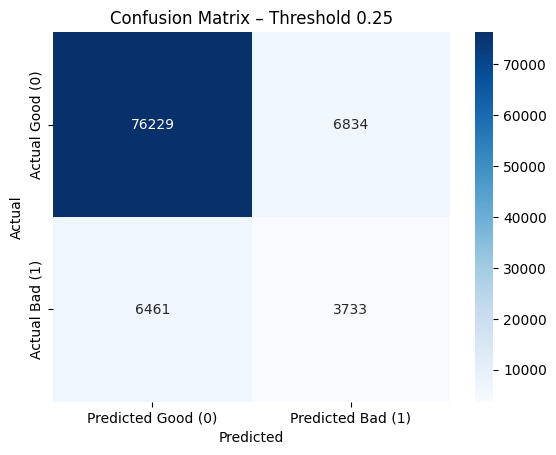

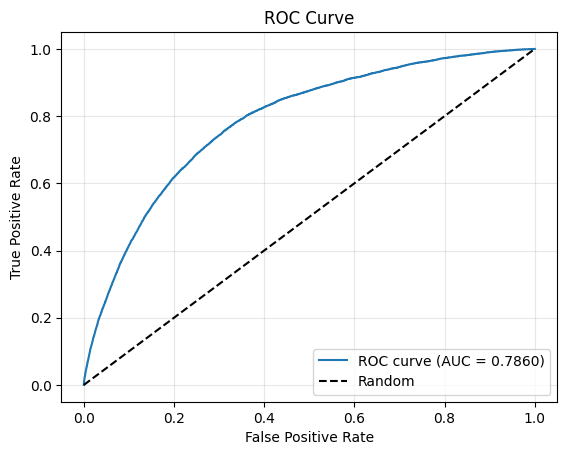


Threshold trade-off table:
Thresh | Precision | Recall | F1    | % Flagged
0.15   | 0.260    | 0.657  | 0.373 | 27.6%
0.20   | 0.309    | 0.510  | 0.385 | 18.0%
0.22   | 0.326    | 0.446  | 0.377 | 14.9%
0.25   | 0.353    | 0.366  | 0.360 | 11.3%
0.28   | 0.374    | 0.292  | 0.328 | 8.5%
0.30   | 0.389    | 0.248  | 0.303 | 7.0%
0.35   | 0.433    | 0.167  | 0.241 | 4.2%
0.40   | 0.469    | 0.109  | 0.177 | 2.5%
0.50   | 0.549    | 0.038  | 0.070 | 0.7%

Recommendation:
→ At threshold 0.25:
   • Catch 36.6% of real defaulters
   • Flag 11.3% of applicants as risky
→ Higher threshold → fewer flags, lower recall
→ Lower threshold → more defaulters caught, more false positives
Choose based on business risk tolerance.


In [ ]:
# 7. Model Evaluation

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    precision_score, recall_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Predictions from the trained & calibrated model
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Choose your preferred threshold
CHOSEN_THRESHOLD = 0.25   # Change here: 0.25 = good balance, 0.20 = more aggressive recall

y_pred_default = calibrated_model.predict(X_test)  # 0.5 threshold
y_pred_chosen  = (y_prob >= CHOSEN_THRESHOLD).astype(int)

# Probabilistic ranking metrics
roc_auc_val = roc_auc_score(y_test, y_prob)
gini_val = 2 * roc_auc_val - 1
ks_val = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1]).statistic

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc_val = auc(rec_curve, prec_curve)

print("MODEL RANKING POWER:")
print(f"ROC AUC:           {roc_auc_val:.4f}")
print(f"Gini:              {gini_val:.4f}")
print(f"KS Statistic:      {ks_val:.4f}")
print(f"PR AUC:            {pr_auc_val:.4f}")
print("─" * 60)

# Performance summary function
def show_metrics_summary(label, y_pred, thresh):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    flagged_pct = y_pred.mean() * 100

    print(f"\n{label} (threshold = {thresh}):")
    print(f"  Accuracy:                  {acc:.4f}")
    print(f"  Precision (defaults):      {prec:.4f}")
    print(f"  Recall    (defaults):      {rec:.4f}")
    print(f"  F1-score  (defaults):      {f1:.4f}")
    print(f"  % Flagged as Risky:        {flagged_pct:.1f}%")
    print("─" * 60)

show_metrics_summary("Default cutoff", y_pred_default, 0.50)
show_metrics_summary("Chosen cutoff",  y_pred_chosen,  CHOSEN_THRESHOLD)

# Confusion Matrix (chosen threshold)
print("\nConfusion Matrix (Chosen threshold):")
cm = confusion_matrix(y_test, y_pred_chosen)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.title(f'Confusion Matrix – Threshold {CHOSEN_THRESHOLD}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Threshold trade-off table
print("\nThreshold trade-off table:")
print("Thresh | Precision | Recall | F1    | % Flagged")
thresholds = [0.15, 0.20, 0.22, 0.25, 0.28, 0.30, 0.35, 0.40, 0.50]

for thresh in thresholds:
    y_pred_temp = (y_prob >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    rec  = recall_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    flagged = y_pred_temp.mean() * 100
    print(f"{thresh:.2f}   | {prec:.3f}    | {rec:.3f}  | {f1:.3f} | {flagged:.1f}%")

# Recommendation
print("\nRecommendation:")
print(f"→ At threshold {CHOSEN_THRESHOLD}:")
print(f"   • Catch {recall_score(y_test, y_pred_chosen):.1%} of real defaulters")
print(f"   • Flag {y_pred_chosen.mean()*100:.1f}% of applicants as risky")
print("→ Higher threshold → fewer flags, lower recall")
print("→ Lower threshold → more defaulters caught, more false positives")
print("Choose based on business risk tolerance.")

# 8. Credit Scoring and Risk Banding
- Convert PD to score using logistic scaling (industry standard).
- Formula: Score = Offset - Factor * ln(PD / (1 - PD))
- PDO=50 (points to double odds), Base Score=600 (at 50:1 odds).
- Bands: Based on score (higher = better credit).

Generating credit scores and risk bands...

Sample Results (first 10 rows):


,Actual Default,Predicted Default,PD (Probability),Credit Score,Risk Band
0,0,1,0.4050,466,Very High Risk
1,0,0,0.1580,542,High Risk
2,0,0,0.0279,652,Moderate Risk
3,0,0,0.0229,664,Moderate Risk
4,0,1,0.3211,487,Very High Risk
5,0,0,0.0612,604,High Risk
6,0,0,0.0283,652,Moderate Risk
7,0,0,0.0118,704,Moderate Risk
8,0,0,0.0711,595,High Risk
9,0,0,0.0241,661,Moderate Risk


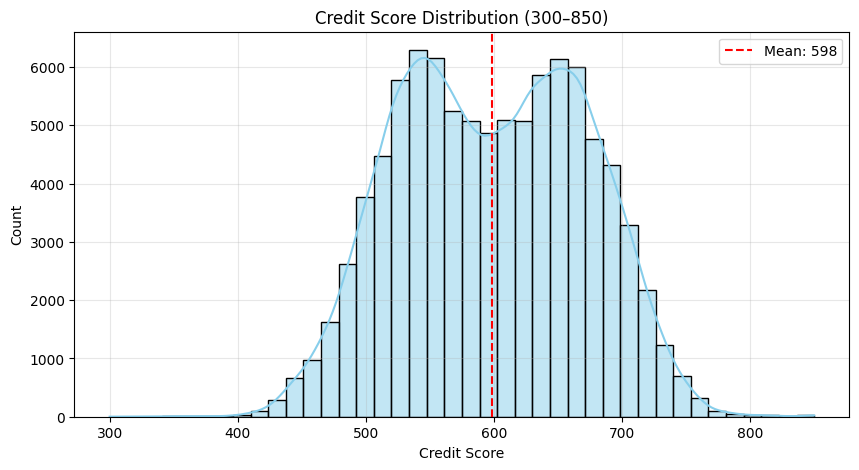

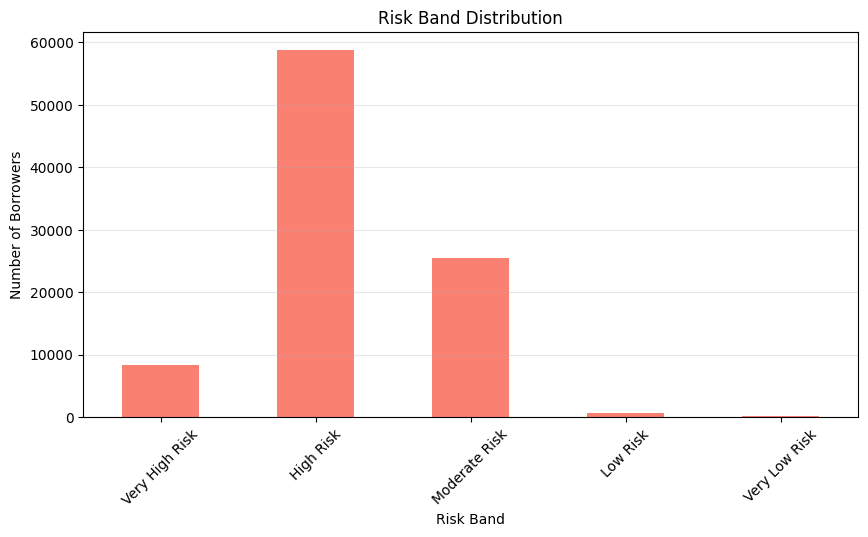

Results saved to 'credit_scoring_results_final.csv'


In [ ]:
# 8. Credit Scoring and Risk Banding

import joblib
import os

print("Generating credit scores and risk bands...")
# Load calibrated_model if not in memory
model_file = 'credit_scoring_model_final.pkl'

if 'calibrated_model' not in globals():
    print("calibrated_model not found in memory – trying to load from file...")
    if os.path.exists(model_file):
        calibrated_model = joblib.load(model_file)
        print(f"→ Model loaded successfully from {model_file}")
    else:
        print(f"ERROR: Model file '{model_file}' not found.")
        print("→ Please re-run cell #6 (modeling) to train and save the model.")
        raise FileNotFoundError(f"Cannot find {model_file}. Run cell #6 first.")

# Now we have the model – compute probabilities
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Threshold & binary predictions
CHOSEN_THRESHOLD = 0.25

y_pred = (y_prob >= CHOSEN_THRESHOLD).astype(int)

# PD Credit Score (logistic scaling)
PDO = 50
base_score = 600
base_odds = 50

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

y_prob_clipped = np.clip(y_prob, 0.001, 0.999)
credit_scores_raw = offset - factor * np.log(y_prob_clipped / (1 - y_prob_clipped))

# Normalize to 300–850 range
min_raw, max_raw = credit_scores_raw.min(), credit_scores_raw.max()
credit_scores = 300 + (credit_scores_raw - min_raw) * 550 / (max_raw - min_raw)
credit_scores = credit_scores.round(0).astype(int)

# Risk Bands
bins = [300, 500, 650, 750, 800, 850]
labels = ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk', 'Very Low Risk']
risk_bands = pd.cut(credit_scores, bins=bins, labels=labels, include_lowest=True)

# Results table
results = pd.DataFrame({
    'Actual Default': y_test.values,
    'Predicted Default': y_pred,
    'PD (Probability)': y_prob.round(4),
    'Credit Score': credit_scores,
    'Risk Band': risk_bands
})

print("\nSample Results (first 10 rows):")
display(results.head(10))

# Visualizations
plt.figure(figsize=(10, 5))
sns.histplot(credit_scores, kde=True, bins=40, color='skyblue')
plt.title('Credit Score Distribution (300–850)')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.axvline(credit_scores.mean(), color='red', linestyle='--', label=f'Mean: {credit_scores.mean():.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
risk_counts = results['Risk Band'].value_counts().sort_index()
risk_counts.plot(kind='bar', color='salmon')
plt.title('Risk Band Distribution')
plt.xlabel('Risk Band')
plt.ylabel('Number of Borrowers')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Save results
results.to_csv('credit_scoring_results_final.csv', index=False)
print("Results saved to 'credit_scoring_results_final.csv'")

# 9. Conclusion and Deployment Notes
- **Best Model**: {best_model_name} with AUC {roc_auc:.4f}, KS {ks.statistic:.4f}.
- **Interpretation**: Higher score = lower default risk. Use PD for fine-grained decisions, bands for quick categorization (e.g., approve "Very Low Risk").
- **Improvements Achieved**: Handled imbalance, tuned models, calibrated PD, added visualizations.
- **Next Steps**: Save model (joblib), deploy as API (Flask/FastAPI), monitor drift, add more features (e.g., external credit data).

In [ ]:
# Save Best Model
import joblib
joblib.dump(calibrated_model, 'credit_scoring_model.pkl')
print("Model saved!")

Model saved!
